# **Customer Churn Prediction & Risk Segmentation**

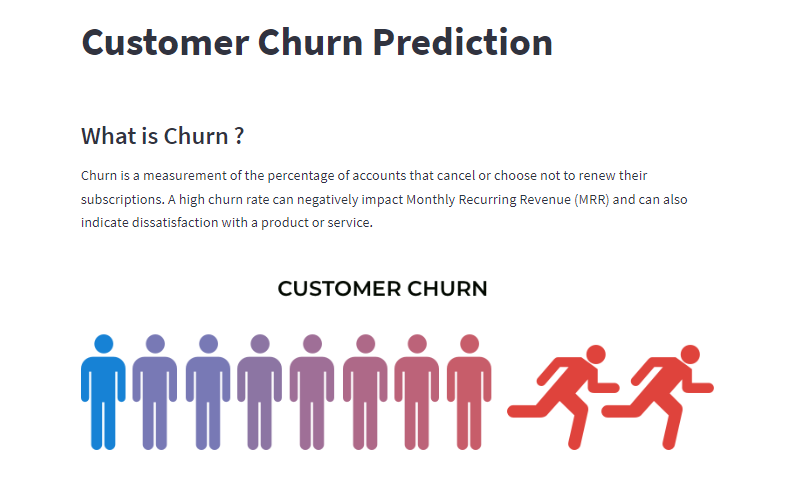

# Dataset Overview

The Telco Customer Churn dataset contains information about the customer base of a telecom company. The dataset includes various attributes related to the customers, their subscription details, and their churn status (whether they left the company or not).

Columns and Their Descriptions

1. CustomerID: Unique identifier for each customer.
2. Count: Not specified; potentially a constant value.
3. Country: Country where the customer resides (all entries are 'United States').
4. State: State where the customer resides.
5. City: City where the customer resides.
6. Zip Code: Postal code of the customer’s location.
7. Lat Long: Latitude and Longitude coordinates of the customer’s location.
8. Latitude: Latitude coordinate of the customer’s location.
9. Longitude: Longitude coordinate of the customer’s location.
10. Gender: Gender of the customer (Male/Female).
11. Senior Citizen: Indicates if the customer is a senior citizen (Yes/No).
12. Partner: Indicates if the customer has a partner (Yes/No).
13. Dependents: Indicates if the customer has dependents (Yes/No).
14. Tenure Months: Number of months the customer has been with the company.
15. Phone Service: Indicates if the customer has phone service (Yes/No).
16. Multiple Lines: Indicates if the customer has multiple lines (Yes/No/No phone service).
17. Internet Service: Type of internet service (DSL, Fiber optic, No).
18. Online Security: Indicates if the customer has online security service (Yes/No/No internet service).
19. Online Backup: Indicates if the customer has online backup service (Yes/No/No internet service).
20. Device Protection: Indicates if the customer has device protection service (Yes/No/No internet service).
21. Tech Support: Indicates if the customer has tech support service (Yes/No/No internet service).
22. Streaming TV: Indicates if the customer has streaming TV service (Yes/No/No internet service).
23. Streaming Movies: Indicates if the customer has streaming movies service (Yes/No/No internet service).
24. Contract: Type of contract (Month-to-month, One year, Two year).
25. Paperless Billing: Indicates if the customer has paperless billing (Yes/No).
26. Payment Method: Method of payment (Electronic check, Mailed check, Bank transfer (automatic), Credit card (automatic)).
27. Monthly Charges: The amount charged to the customer monthly.
28. Total Charges: The total amount charged to the customer.
29. Churn Label: Indicates if the customer churned (Yes/No).
30. Churn Value: Binary value for churn (0 = No, 1 = Yes).
31. Churn Score: Score indicating the likelihood of churn (higher score indicates higher likelihood).
32. CLTV: Customer Lifetime Value.
33. Churn Reason: Reason for churn (filled for customers who churned).

# Purpose Of Dataset

The primary purpose of this dataset is to analyze and predict customer churn. By understanding the factors that contribute to churn, the telecom company can develop strategies to retain customers and reduce churn rates.

# **Importing The Libraries**

In [95]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

**Data Understanding**

In [96]:
df = pd.read_excel("Telco_customer_churn.xlsx")
df

,CustomerID,Count,Country,State,City,Zip Code,Lat Long,Latitude,Longitude,Gender,...,Contract,Paperless Billing,Payment Method,Monthly Charges,Total Charges,Churn Label,Churn Value,Churn Score,CLTV,Churn Reason
0,3668-QPYBK,1,United States,California,Los Angeles,90003,"33.964131, -118.272783",33.964131,-118.272783,Male,...,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,1,86,3239,Competitor made better offer
1,9237-HQITU,1,United States,California,Los Angeles,90005,"34.059281, -118.30742",34.059281,-118.307420,Female,...,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,1,67,2701,Moved
2,9305-CDSKC,1,United States,California,Los Angeles,90006,"34.048013, -118.293953",34.048013,-118.293953,Female,...,Month-to-month,Yes,Electronic check,99.65,820.5,Yes,1,86,5372,Moved
3,7892-POOKP,1,United States,California,Los Angeles,90010,"34.062125, -118.315709",34.062125,-118.315709,Female,...,Month-to-month,Yes,Electronic check,104.80,3046.05,Yes,1,84,5003,Moved
4,0280-XJGEX,1,United States,California,Los Angeles,90015,"34.039224, -118.266293",34.039224,-118.266293,Male,...,Month-to-month,Yes,Bank transfer (automatic),103.70,5036.3,Yes,1,89,5340,Competitor had better devices
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,2569-WGERO,1,United States,California,Landers,92285,"34.341737, -116.539416",34.341737,-116.539416,Female,...,Two year,Yes,Bank transfer (automatic),21.15,1419.4,No,0,45,5306,NaN
7039,6840-RESVB,1,United States,California,Adelanto,92301,"34.667815, -117.536183",34.667815,-117.536183,Male,...,One year,Yes,Mailed check,84.80,1990.5,No,0,59,2140,NaN
7040,2234-XADUH,1,United States,California,Amboy,92304,"34.559882, -115.637164",34.559882,-115.637164,Female,...,One year,Yes,Credit card (automatic),103.20,7362.9,No,0,71,5560,NaN
7041,4801-JZAZL,1,United States,California,Angelus Oaks,92305,"34.1678, -116.86433",34.167800,-116.864330,Female,...,Month-to-month,Yes,Electronic check,29.60,346.45,No,0,59,2793,NaN


**Check Top 10 Rows of the Dataset**

In [97]:
df.head(10)

,CustomerID,Count,Country,State,City,Zip Code,Lat Long,Latitude,Longitude,Gender,...,Contract,Paperless Billing,Payment Method,Monthly Charges,Total Charges,Churn Label,Churn Value,Churn Score,CLTV,Churn Reason
0,3668-QPYBK,1,United States,California,Los Angeles,90003,"33.964131, -118.272783",33.964131,-118.272783,Male,...,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,1,86,3239,Competitor made better offer
1,9237-HQITU,1,United States,California,Los Angeles,90005,"34.059281, -118.30742",34.059281,-118.307420,Female,...,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,1,67,2701,Moved
2,9305-CDSKC,1,United States,California,Los Angeles,90006,"34.048013, -118.293953",34.048013,-118.293953,Female,...,Month-to-month,Yes,Electronic check,99.65,820.5,Yes,1,86,5372,Moved
3,7892-POOKP,1,United States,California,Los Angeles,90010,"34.062125, -118.315709",34.062125,-118.315709,Female,...,Month-to-month,Yes,Electronic check,104.80,3046.05,Yes,1,84,5003,Moved
4,0280-XJGEX,1,United States,California,Los Angeles,90015,"34.039224, -118.266293",34.039224,-118.266293,Male,...,Month-to-month,Yes,Bank transfer (automatic),103.70,5036.3,Yes,1,89,5340,Competitor had better devices
5,4190-MFLUW,1,United States,California,Los Angeles,90020,"34.066367, -118.309868",34.066367,-118.309868,Female,...,Month-to-month,No,Credit card (automatic),55.20,528.35,Yes,1,78,5925,Competitor offered higher download speeds
6,8779-QRDMV,1,United States,California,Los Angeles,90022,"34.02381, -118.156582",34.023810,-118.156582,Male,...,Month-to-month,Yes,Electronic check,39.65,39.65,Yes,1,100,5433,Competitor offered more data
7,1066-JKSGK,1,United States,California,Los Angeles,90024,"34.066303, -118.435479",34.066303,-118.435479,Male,...,Month-to-month,No,Mailed check,20.15,20.15,Yes,1,92,4832,Competitor made better offer
8,6467-CHFZW,1,United States,California,Los Angeles,90028,"34.099869, -118.326843",34.099869,-118.326843,Male,...,Month-to-month,Yes,Electronic check,99.35,4749.15,Yes,1,77,5789,Competitor had better devices
9,8665-UTDHZ,1,United States,California,Los Angeles,90029,"34.089953, -118.294824",34.089953,-118.294824,Male,...,Month-to-month,No,Electronic check,30.20,30.2,Yes,1,97,2915,Competitor had better devices


**Check Last 10 Rows of the Dataset**

In [98]:
df.tail(10)

,CustomerID,Count,Country,State,City,Zip Code,Lat Long,Latitude,Longitude,Gender,...,Contract,Paperless Billing,Payment Method,Monthly Charges,Total Charges,Churn Label,Churn Value,Churn Score,CLTV,Churn Reason
7033,0871-OPBXW,1,United States,California,Twentynine Palms,92277,"34.17211, -115.769773",34.172110,-115.769773,Female,...,Month-to-month,Yes,Mailed check,20.05,39.25,No,0,80,5191,NaN
7034,3605-JISKB,1,United States,California,Twentynine Palms,92278,"34.457829, -116.139589",34.457829,-116.139589,Male,...,One year,No,Credit card (automatic),60.00,3316.1,No,0,71,4212,NaN
7035,9767-FFLEM,1,United States,California,Westmorland,92281,"33.03679, -115.60503",33.036790,-115.605030,Male,...,Month-to-month,Yes,Credit card (automatic),69.50,2625.25,No,0,35,4591,NaN
7036,8456-QDAVC,1,United States,California,Winterhaven,92283,"32.852947, -114.850784",32.852947,-114.850784,Male,...,Month-to-month,Yes,Bank transfer (automatic),78.70,1495.1,No,0,20,2464,NaN
7037,7750-EYXWZ,1,United States,California,Yucca Valley,92284,"34.159534, -116.425984",34.159534,-116.425984,Female,...,One year,No,Electronic check,60.65,743.3,No,0,24,3740,NaN
7038,2569-WGERO,1,United States,California,Landers,92285,"34.341737, -116.539416",34.341737,-116.539416,Female,...,Two year,Yes,Bank transfer (automatic),21.15,1419.4,No,0,45,5306,NaN
7039,6840-RESVB,1,United States,California,Adelanto,92301,"34.667815, -117.536183",34.667815,-117.536183,Male,...,One year,Yes,Mailed check,84.80,1990.5,No,0,59,2140,NaN
7040,2234-XADUH,1,United States,California,Amboy,92304,"34.559882, -115.637164",34.559882,-115.637164,Female,...,One year,Yes,Credit card (automatic),103.20,7362.9,No,0,71,5560,NaN
7041,4801-JZAZL,1,United States,California,Angelus Oaks,92305,"34.1678, -116.86433",34.167800,-116.864330,Female,...,Month-to-month,Yes,Electronic check,29.60,346.45,No,0,59,2793,NaN
7042,3186-AJIEK,1,United States,California,Apple Valley,92308,"34.424926, -117.184503",34.424926,-117.184503,Male,...,Two year,Yes,Bank transfer (automatic),105.65,6844.5,No,0,38,5097,NaN


**Shape of Dataset**

In [99]:
df.shape

(7043, 33)

**Data type of each column**

In [100]:
df.dtypes

CustomerID               str
Count                  int64
Country                  str
State                    str
City                     str
Zip Code               int64
Lat Long                 str
Latitude             float64
Longitude            float64
Gender                   str
Senior Citizen           str
Partner                  str
Dependents               str
Tenure Months          int64
Phone Service            str
Multiple Lines           str
Internet Service         str
Online Security          str
Online Backup            str
Device Protection        str
Tech Support             str
Streaming TV             str
Streaming Movies         str
Contract                 str
Paperless Billing        str
Payment Method           str
Monthly Charges      float64
Total Charges         object
Churn Label              str
Churn Value            int64
Churn Score            int64
CLTV                   int64
Churn Reason             str
dtype: object

**Find number of rows and number of columns**

In [101]:
print("No of Rows:",df.shape[0])
print("No of columns:",df.shape[1])

No of Rows: 7043
No of columns: 33


**Get the Information About Our Dataset Like Total Number of Rows, Total Number of Columns, Datatypes of Each Column And Memory Requirment**

In [102]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 33 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   CustomerID         7043 non-null   str    
 1   Count              7043 non-null   int64  
 2   Country            7043 non-null   str    
 3   State              7043 non-null   str    
 4   City               7043 non-null   str    
 5   Zip Code           7043 non-null   int64  
 6   Lat Long           7043 non-null   str    
 7   Latitude           7043 non-null   float64
 8   Longitude          7043 non-null   float64
 9   Gender             7043 non-null   str    
 10  Senior Citizen     7043 non-null   str    
 11  Partner            7043 non-null   str    
 12  Dependents         7043 non-null   str    
 13  Tenure Months      7043 non-null   int64  
 14  Phone Service      7043 non-null   str    
 15  Multiple Lines     7043 non-null   str    
 16  Internet Service   7043 non-null   

**Check Null Values in the Dataset**

In [103]:
df.isnull().sum()

CustomerID              0
Count                   0
Country                 0
State                   0
City                    0
Zip Code                0
Lat Long                0
Latitude                0
Longitude               0
Gender                  0
Senior Citizen          0
Partner                 0
Dependents              0
Tenure Months           0
Phone Service           0
Multiple Lines          0
Internet Service        0
Online Security         0
Online Backup           0
Device Protection       0
Tech Support            0
Streaming TV            0
Streaming Movies        0
Contract                0
Paperless Billing       0
Payment Method          0
Monthly Charges         0
Total Charges           0
Churn Label             0
Churn Value             0
Churn Score             0
CLTV                    0
Churn Reason         5174
dtype: int64

**The value 'No Reason' is used to replace all missing values in the Churn Reason column.**

In [104]:
df['Churn Reason']=df['Churn Reason'].fillna('No Reason')

In [105]:
df['Churn Reason'].value_counts()

Churn Reason
No Reason                                    5174
Attitude of support person                    192
Competitor offered higher download speeds     189
Competitor offered more data                  162
Don't know                                    154
Competitor made better offer                  140
Attitude of service provider                  135
Competitor had better devices                 130
Network reliability                           103
Product dissatisfaction                       102
Price too high                                 98
Service dissatisfaction                        89
Lack of self-service on Website                88
Extra data charges                             57
Moved                                          53
Limited range of services                      44
Lack of affordable download/upload speed       44
Long distance charges                          44
Poor expertise of phone support                20
Poor expertise of online support     

**Checking if there are any null values present in the dataset or not**

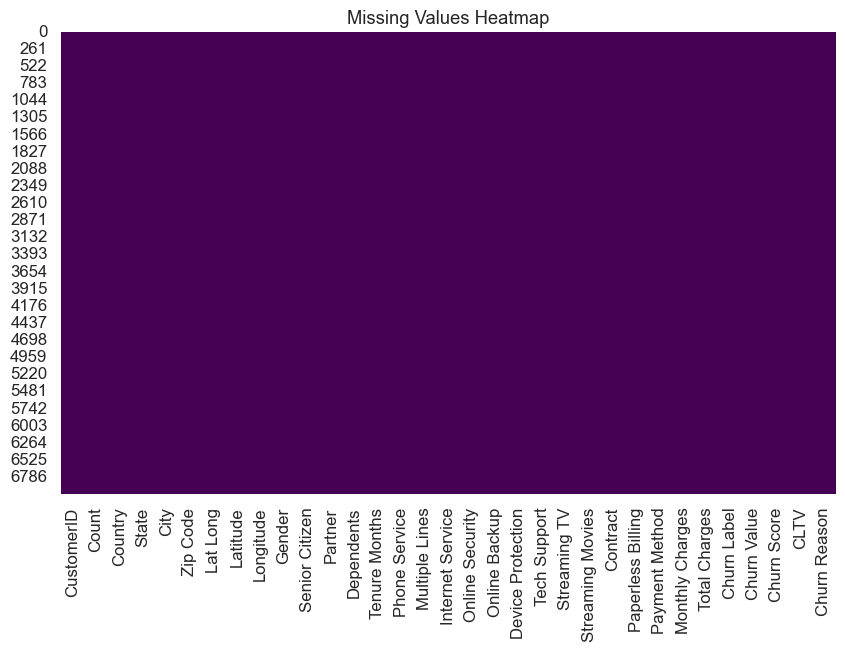

In [106]:
plt.figure(figsize=(10, 6))
sns.heatmap(df.isnull(), cbar=False, cmap='viridis')
plt.title('Missing Values Heatmap')
plt.show()

**Insight**: The heatmap shows the correlation between different features. Strong correlations (values close to 1 or -1) indicate features that may be redundant or highly related. For churn prediction, we should focus on features that have a strong correlation with churn.

# **Preprocessing and Feature Engineering**

Data Cleaning and Transformation This section handles missing values, outliers, and ensures data consistency. We also apply feature transformations such as scaling and encoding to prepare the dataset for modeling. Below is a detailed breakdown of the steps applied to the Telco Customer Churn dataset:

**Checking if there are any duplicate values present in the dataset or not ?**

In [107]:
df.duplicated().sum()

np.int64(0)

**Identifying all the categorical columns in the dataset**

In [108]:
cato_cols = df.select_dtypes(include='object').columns
cato_cols

C:\Users\jinit\AppData\Local\Temp\ipykernel_18148\2309817920.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cato_cols = df.select_dtypes(include='object').columns


Index(['CustomerID', 'Country', 'State', 'City', 'Lat Long', 'Gender',
       'Senior Citizen', 'Partner', 'Dependents', 'Phone Service',
       'Multiple Lines', 'Internet Service', 'Online Security',
       'Online Backup', 'Device Protection', 'Tech Support', 'Streaming TV',
       'Streaming Movies', 'Contract', 'Paperless Billing', 'Payment Method',
       'Total Charges', 'Churn Label', 'Churn Reason'],
      dtype='str')

**identifying all the numerical columns in the dataset**

In [109]:
noum_cols = df.select_dtypes(exclude='object').columns
noum_cols

Index(['Count', 'Zip Code', 'Latitude', 'Longitude', 'Tenure Months',
       'Monthly Charges', 'Churn Value', 'Churn Score', 'CLTV'],
      dtype='str')

**Convert TotalCharges to Numeric**

In [110]:
df["Total Charges"] = pd.to_numeric(df["Total Charges"], errors="coerce")

In [111]:
df['Total Charges'] = df['Total Charges'].fillna(0)

In [112]:
print(df['Total Charges'].dtype)

float64


In [113]:
df.isnull().sum()

CustomerID           0
Count                0
Country              0
State                0
City                 0
Zip Code             0
Lat Long             0
Latitude             0
Longitude            0
Gender               0
Senior Citizen       0
Partner              0
Dependents           0
Tenure Months        0
Phone Service        0
Multiple Lines       0
Internet Service     0
Online Security      0
Online Backup        0
Device Protection    0
Tech Support         0
Streaming TV         0
Streaming Movies     0
Contract             0
Paperless Billing    0
Payment Method       0
Monthly Charges      0
Total Charges        0
Churn Label          0
Churn Value          0
Churn Score          0
CLTV                 0
Churn Reason         0
dtype: int64

**Removal of Constant-Value Features**

Some features contain the same value across all observations, resulting in zero variance. These variables do not provide any discriminatory power and therefore do not contribute to the analysis or modeling process.

Based on the variable-level inspection, the following columns were identified as constant-value features and were removed from the dataset:

* Count
* Country
* State
Removing these features simplifies the dataset without any loss of information.

In [114]:
df.drop(columns=["Count", "Country", "State"], inplace=True)

**Removal of Identifier Features**

Some variables act purely as unique identifiers rather than informative features. These variables are designed to uniquely identify each observation and do not capture any behavioral or business-related patterns.

The CustomerID column contains a unique value for each record and therefore does not provide any predictive or analytical value. Including it in the analysis would only introduce noise and potential data leakage.

For this reason, CustomerID was removed from the dataset.

In [115]:
df.drop(columns="CustomerID", inplace=True)

In [116]:
df.columns

Index(['City', 'Zip Code', 'Lat Long', 'Latitude', 'Longitude', 'Gender',
       'Senior Citizen', 'Partner', 'Dependents', 'Tenure Months',
       'Phone Service', 'Multiple Lines', 'Internet Service',
       'Online Security', 'Online Backup', 'Device Protection', 'Tech Support',
       'Streaming TV', 'Streaming Movies', 'Contract', 'Paperless Billing',
       'Payment Method', 'Monthly Charges', 'Total Charges', 'Churn Label',
       'Churn Value', 'Churn Score', 'CLTV', 'Churn Reason'],
      dtype='str')

**Get Overall Statistics About in the Dataset**

In [117]:
df.describe()

,Zip Code,Latitude,Longitude,Tenure Months,Monthly Charges,Total Charges,Churn Value,Churn Score,CLTV
count,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000
mean,93521.964646,36.282441,-119.798880,32.371149,64.761692,2279.734304,0.265370,58.699418,4400.295755
std,1865.794555,2.455723,2.157889,24.559481,30.090047,2266.794470,0.441561,21.525131,1183.057152
min,90001.000000,32.555828,-124.301372,0.000000,18.250000,0.000000,0.000000,5.000000,2003.000000
25%,92102.000000,34.030915,-121.815412,9.000000,35.500000,398.550000,0.000000,40.000000,3469.000000
50%,93552.000000,36.391777,-119.730885,29.000000,70.350000,1394.550000,0.000000,61.000000,4527.000000
75%,95351.000000,38.224869,-118.043237,55.000000,89.850000,3786.600000,1.000000,75.000000,5380.500000
max,96161.000000,41.962127,-114.192901,72.000000,118.750000,8684.800000,1.000000,100.000000,6500.000000


# **Data Visualization**

Exploratory Data Analysis (EDA) This section focuses on visualizing the dataset to uncover patterns, trends, and relationships between features. Data visualization helps us better understand the data, identify potential insights, and guide further analysis. Below is a detailed breakdown of the steps applied to the Telco Customer Churn dataset

In [118]:
# 1. Set the background style
sns.set_theme(style="whitegrid", font_scale=1.1)
colors = {
    "No": "#1f77b4",
    "Yes": "#e74c3c"
}

def add_labels(ax):
    for container in ax.containers:
        ax.bar_label(container, fontsize=10, fontweight='bold', padding=3)

# **Customer Churn Distribution**

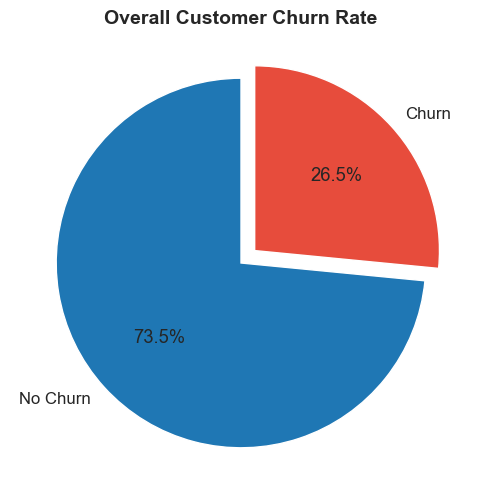

In [119]:
churn_counts = df["Churn Value"].value_counts()

plt.figure(figsize=(6,6))

plt.pie(
    churn_counts,
    labels=["No Churn", "Churn"],
    autopct="%1.1f%%",
    colors=[colors["No"], colors["Yes"]],
    startangle=90,
    explode=(0, 0.1)
)

plt.title("Overall Customer Churn Rate", fontsize=14, fontweight="bold")

plt.show()

Most customers do not churn, but a significant portion leaves the service, indicating a need for proactive retention strategies.

# **Relationship between Monthly Charges and Churn Status using two different types of plots**

**Box Plot:**
* Shows the distribution of Monthly Charges for customers who churned ("Yes") and those who did not ("No").
* Highlights the median, quartiles, and potential outliers.

**Bar Plot:**
* Displays the mean of Monthly Charges for each churn status.
* Helps compare the average monthly charges between churned and non-churned customers.

C:\Users\jinit\AppData\Local\Temp\ipykernel_18148\1867339684.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Churn Label', y='Monthly Charges', data=df, palette=colors, ax=axes[0])
C:\Users\jinit\AppData\Local\Temp\ipykernel_18148\1867339684.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Churn Label', y='Monthly Charges', data=df, palette=colors, ax=axes[1], estimator='mean')


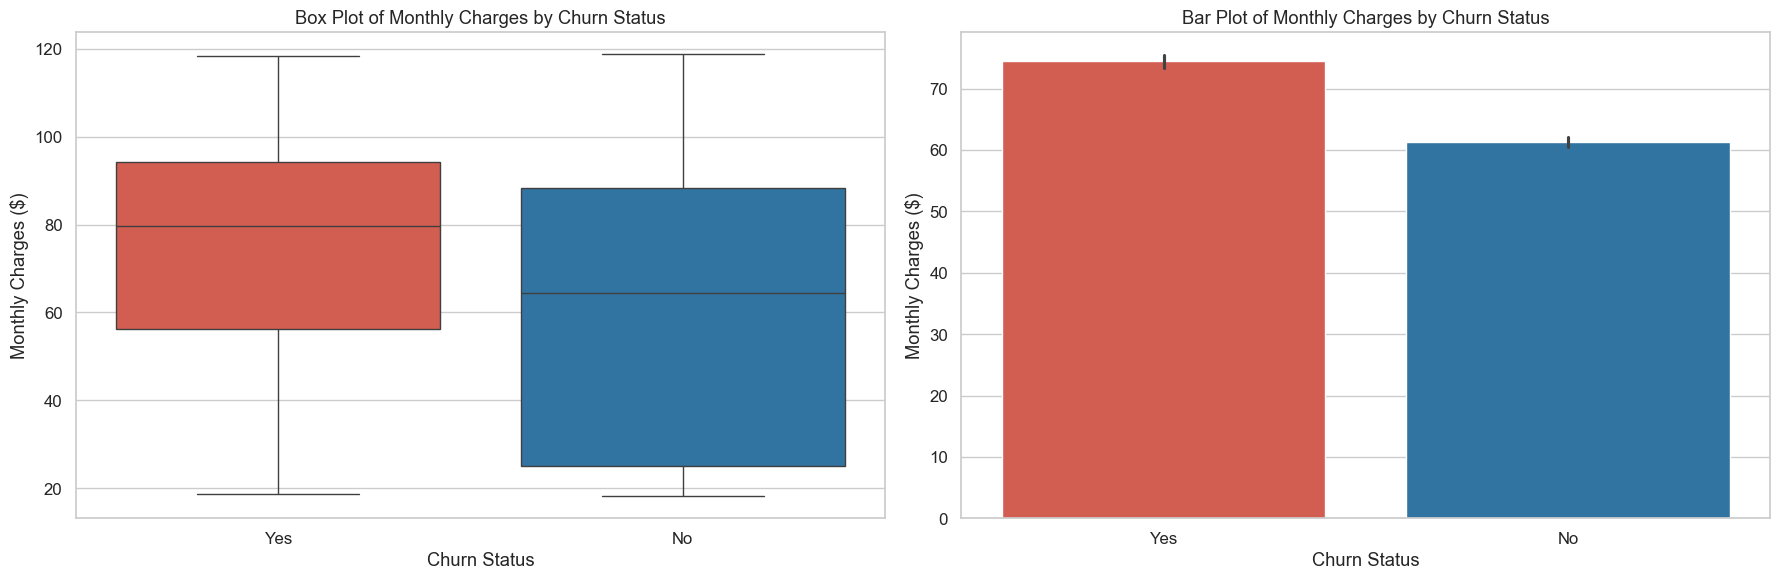

In [120]:
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

sns.boxplot(x='Churn Label', y='Monthly Charges', data=df, palette=colors, ax=axes[0])
axes[0].set_xlabel("Churn Status")
axes[0].set_ylabel("Monthly Charges ($)")
axes[0].set_title("Box Plot of Monthly Charges by Churn Status")

sns.barplot(x='Churn Label', y='Monthly Charges', data=df, palette=colors, ax=axes[1], estimator='mean')
axes[1].set_xlabel("Churn Status")
axes[1].set_ylabel("Monthly Charges ($)")
axes[1].set_title("Bar Plot of Monthly Charges by Churn Status")

plt.tight_layout()
plt.show()


**Insight:**
Through data analysis, it was observed that customers who left the company (churned) had a higher average monthly payment (Monthly Charge) compared to customers who stayed. In other words, the average monthly payment of customers who churned is higher than that of customers who remained with the company.

# **Relationship between Tenure Months and Total Charges using three different types of visualizations**

**Scatter Plot:**
* Shows the relationship between Tenure Months and Total Charges as individual data points.
* Helps identify trends, clusters, or outliers in the data.

**Line Plot:**
* Displays the trend of Total Charges as Tenure Months increases.
* Useful for understanding how total charges accumulate over time.

**Correlation Heatmap:**
* Calculates and visualizes the correlation coefficient between Tenure Months and Total Charges.
* Provides a quantitative measure of the strength and direction of their relationship.

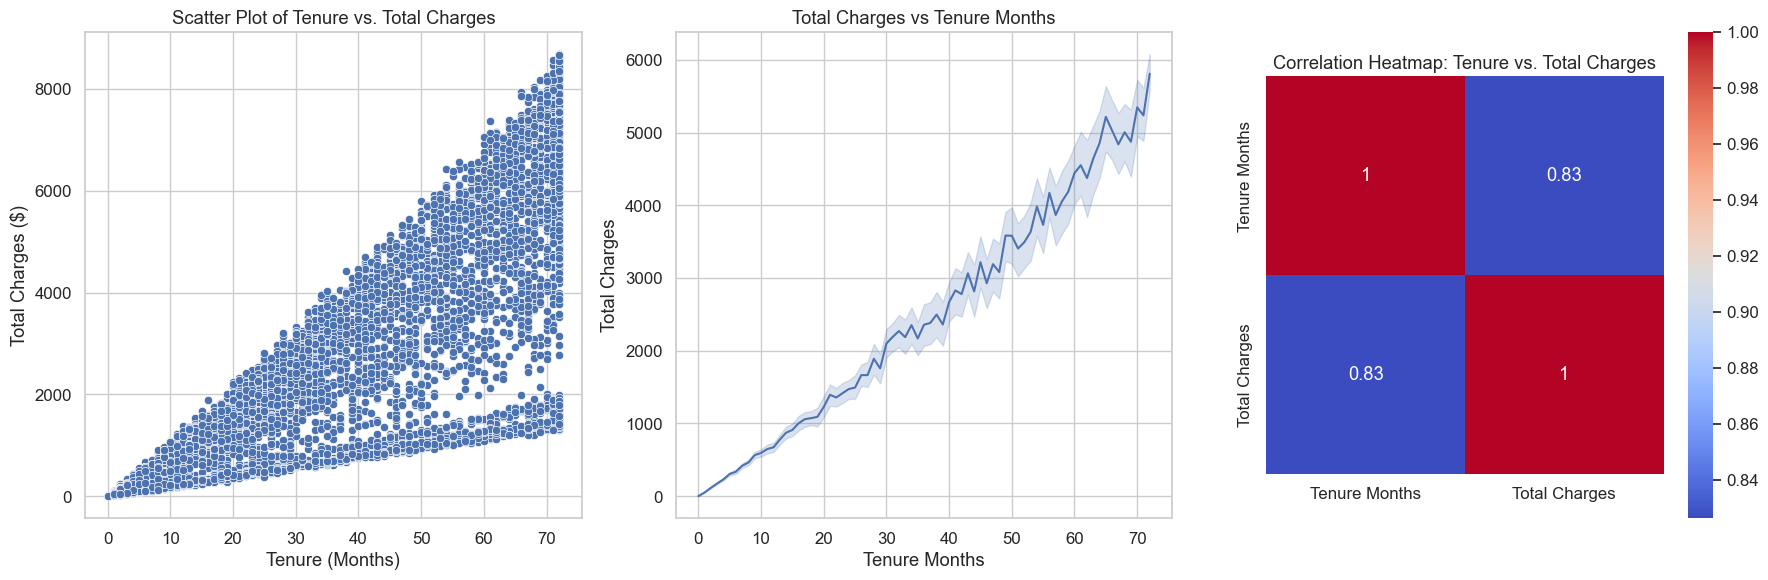

In [121]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

sns.scatterplot(x='Tenure Months', y='Total Charges', data=df, ax=axes[0])
axes[0].set_xlabel("Tenure (Months)")
axes[0].set_ylabel("Total Charges ($)")
axes[0].set_title("Scatter Plot of Tenure vs. Total Charges")

sns.lineplot(x='Tenure Months', y='Total Charges', data=df, ax=axes[1])
axes[1].set_title('Total Charges vs Tenure Months')
axes[1].set_xlabel('Tenure Months')
axes[1].set_ylabel('Total Charges')

corr_df = df[['Tenure Months', 'Total Charges']].corr()
sns.heatmap(corr_df, annot=True, cmap='coolwarm', square=True, ax=axes[2])
axes[2].set_title("Correlation Heatmap: Tenure vs. Total Charges")

plt.tight_layout()
plt.show()

**Insights:** 

**Scatter**
* The scatter plot shows a positive correlation between the variables, indicating that as one variable increases, the other variable also tends to increase.
* The data points are scattered around the trend line, suggesting that there may be some random variation in the data.
line
* Positive Correlation: As tenure increases, total charges also increase, which is expected since customers pay more over time.
* Non-Linear Trend: Some fluctuations may indicate:
* Customers with higher tenure but lower charges (possible discounts or downgrades).
* Customers with lower tenure but higher charges (premium plans or additional services).
* Gaps in Data: If there are gaps, it might be due to missing data or customers with incomplete billing.

**heatmap**
* Strong Positive Correlation (~0.83)
* Tenure Months and Total Charges have a very high correlation, meaning longer tenure directly leads to higher total     charges.

**Linear Relationship**
* This suggests a strong linear trend, where total charges increase consistently as tenure increases.

# **Relationship between Contract Type and Churn using two complementary visualizations**

**Stacked Bar Plot:**
* Groups the data by Contract Type and Churn Label, then visualizes the counts of churned and non-churned customers for each contract type as stacked bars.
* Helps compare the proportion of churned vs. non-churned customers across different contract types.

**Count Plot:**
* Uses a grouped bar plot to show the count of churned and non-churned customers for each contract type side by side.
* Provides a clear comparison of churn rates across contract types.

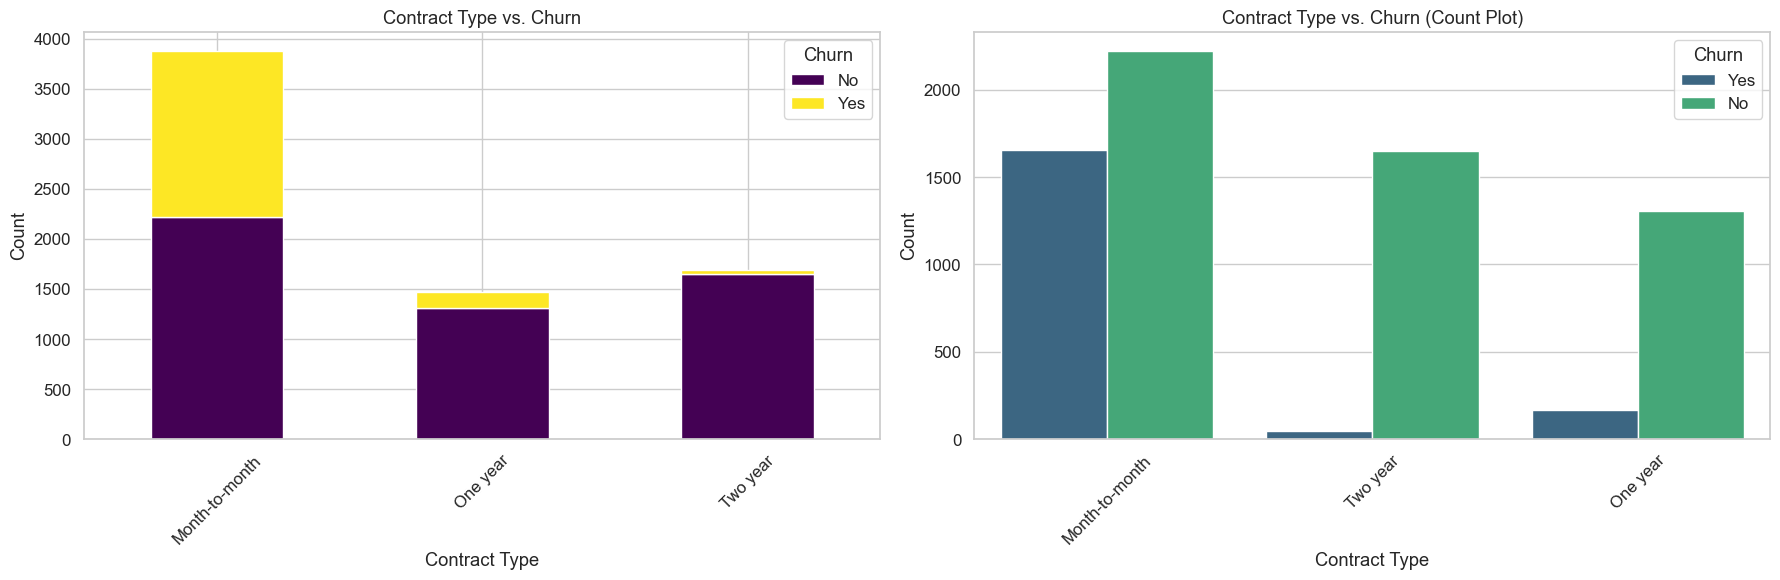

In [122]:
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

contract_churn_counts = df.groupby(["Contract", "Churn Label"]).size().unstack()
contract_churn_counts.plot(kind="bar", stacked=True, colormap="viridis", ax=axes[0])
axes[0].set_xlabel("Contract Type")
axes[0].set_ylabel("Count")
axes[0].set_title("Contract Type vs. Churn")
axes[0].legend(title="Churn")
axes[0].tick_params(axis='x', rotation=45)

sns.countplot(data=df, x="Contract", hue="Churn Label", palette="viridis", ax=axes[1])
axes[1].set_xlabel("Contract Type")
axes[1].set_ylabel("Count")
axes[1].set_title("Contract Type vs. Churn (Count Plot)")
axes[1].tick_params(axis='x', rotation=45)
axes[1].legend(title="Churn")

plt.tight_layout()
plt.show()

**Insights:**

**1.Month-to-Month Contracts Have the Highest Churn Rate**
* 42.7% of customers on a month-to-month contract churned.
* This contract type is more flexible, making it easier for customers to leave.

**2.One-Year Contracts Have Moderate Churn**
* Only 11.3% of customers churned.
* Customers with longer commitments are less likely to leave.

**3.Two-Year Contracts Have the Lowest Churn**
* Just 2.8% of customers churned.
* Longer-term contracts likely provide more stability and commitment.

# **Visualize the distribution of the Monthly Charges feature using two complementary plots**

**Histogram:**
* Displays the frequency distribution of Monthly Charges using bins.
* Helps identify the range and concentration of monthly charges across customers.

**Kernel Density Estimate (KDE) Plot:**
* Provides a smoothed estimate of the distribution of Monthly Charges.

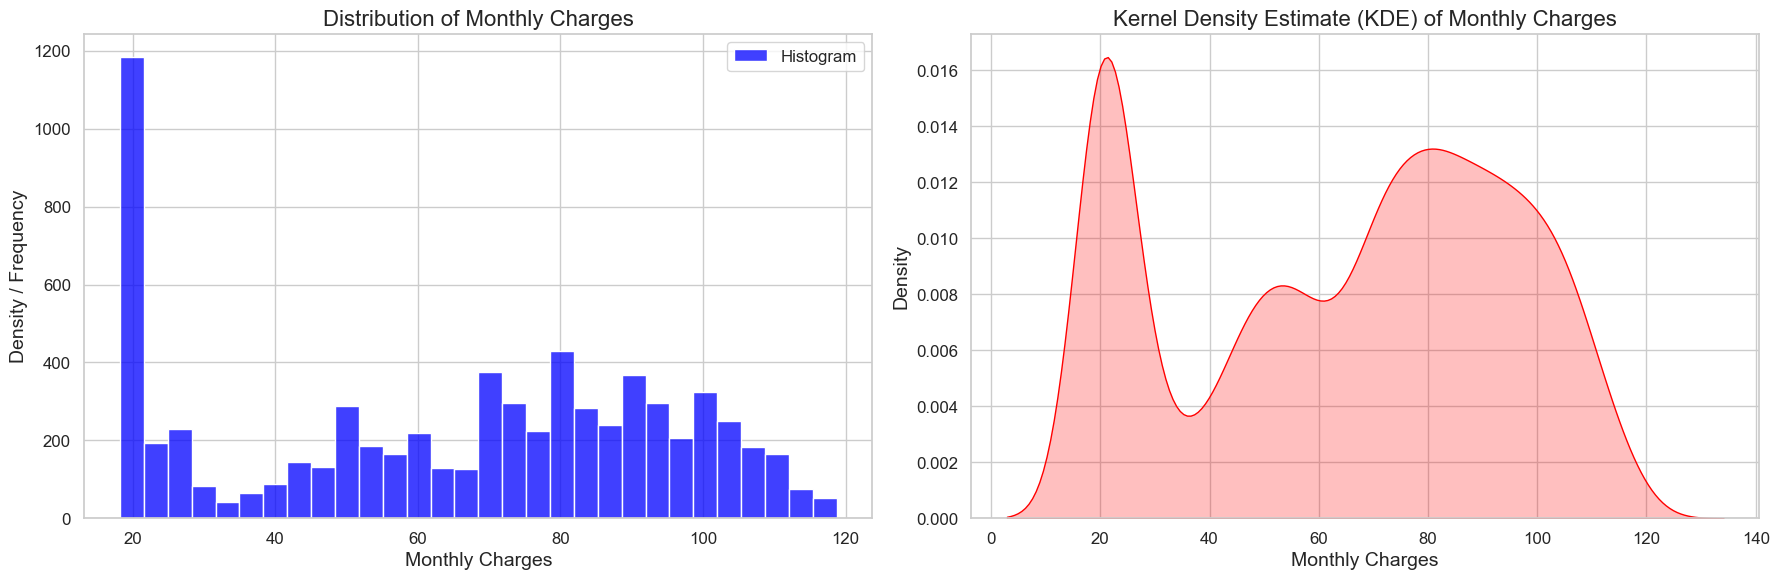

In [123]:
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

sns.histplot(df['Monthly Charges'], kde=False, bins=30, color='blue', label='Histogram', ax=axes[0])
axes[0].set_title('Distribution of Monthly Charges', fontsize=16)
axes[0].set_xlabel('Monthly Charges', fontsize=14)
axes[0].set_ylabel('Density / Frequency', fontsize=14)
axes[0].legend()

sns.kdeplot(df['Monthly Charges'], color='red', fill=True, ax=axes[1])
axes[1].set_title('Kernel Density Estimate (KDE) of Monthly Charges', fontsize=16)
axes[1].set_xlabel('Monthly Charges', fontsize=14)
axes[1].set_ylabel('Density', fontsize=14)

plt.tight_layout()
plt.show()

# **Correlation heatmap to visualize the relationships between three key numerical features**

**Total Charges:** The total amount paid by the customer.

**Monthly Charges:** The monthly subscription fee.

**Tenure Months:** The number of months the customer has been with the company.

The heatmap uses a color gradient (from coolwarm) to represent the strength and direction of the correlation, with values annotated on each cell.

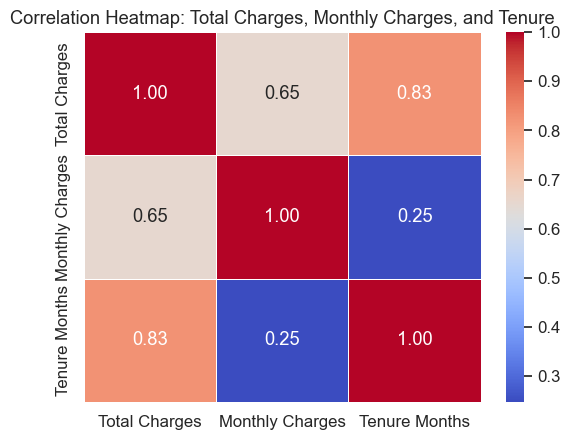

In [124]:
corr_features = df[["Total Charges", "Monthly Charges", "Tenure Months"]].corr()
sns.heatmap(corr_features, annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)
plt.title("Correlation Heatmap: Total Charges, Monthly Charges, and Tenure")
plt.show()

**Insights:**

**1.Total Charges vs. Tenure Months (0.83 - Strong Positive Correlation)**
* As tenure increases, total charges increase, which is expected since longer-tenured customers accumulate higher total payments.

**2.Total Charges vs. Monthly Charges (0.65 - Moderate Positive Correlation)**
* Customers with higher monthly charges tend to have higher total charges, but the correlation isn't perfect since tenure also plays a role.

**3.Monthly Charges vs. Tenure Months (0.25 - Weak Positive Correlation)**
* This weak correlation suggests that customers with longer tenures do not necessarily have higher monthly charges. Some long-term customers might be on legacy or discounted plans.

# **Creating a pairplot to visualize pairwise relationships between three key numerical features:**

**Total Charges:** The total amount paid by the customer.

**Monthly Charges:** The monthly subscription fee.

**Tenure Months:** The number of months the customer has been with the company.

**The pairplot includes:**

* Scatterplots for pairwise relationships between the features.

Kernel Density Estimate (KDE) plots on the diagonal to show the distribution of each feature.

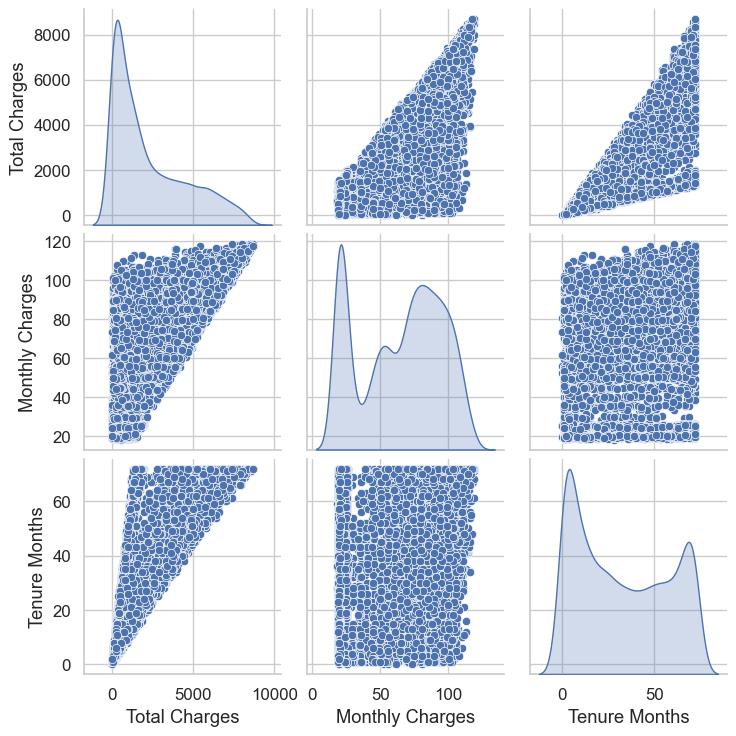

In [125]:
sns.pairplot(df[["Total Charges", "Monthly Charges", "Tenure Months"]], diag_kind="kde")
plt.show()

**Insights:**

**1.Total Charges vs. Tenure Months (Strong Positive Trend)**
* This scatter plot should show an upward diagonal pattern, reinforcing their strong correlation (0.83).
* A few outliers might exist due to missing or incorrect total charges at low tenures.

**2.Total Charges vs. Monthly Charges (Moderate Positive Trend)**
* The plot should show an upward trend, but with more spread, indicating variability in total charges for customers with similar monthly charges.

**3.Monthly Charges vs. Tenure Months (Weak Correlation, Likely No Clear Trend)**
* The scatter plot might appear widely dispersed, confirming the weak correlation (0.25).
* This suggests that tenure length does not strongly determine how much a customer pays per month.

# **Compare two key features (Monthly Charges and Tenure Months) against the target variable (Churn Label) using boxplots.**

**Churn Label vs. Monthly Charges:**
* Compares the distribution of Monthly Charges for customers who churned ("Yes") and those who did not ("No").
* Highlights the median, quartiles, and potential outliers for each group.

**Churn Label vs. Tenure Months:**
* Compares the distribution of Tenure Months for customers who churned ("Yes") and those who did not ("No").
* Shows how long customers stayed with the company before churning.

C:\Users\jinit\AppData\Local\Temp\ipykernel_18148\1197475267.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="Churn Label", y="Monthly Charges", palette=colors, ax=axes[0])
C:\Users\jinit\AppData\Local\Temp\ipykernel_18148\1197475267.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="Churn Label", y="Tenure Months", palette=colors, ax=axes[1])


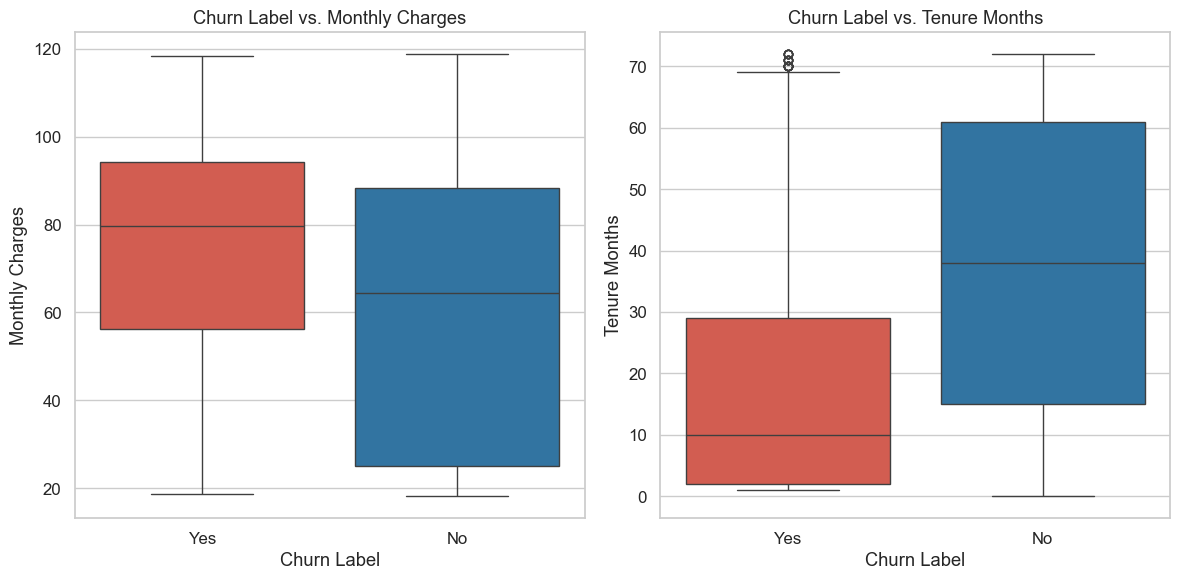

In [127]:
fig, axes = plt.subplots(1, 2, figsize=(12, 6))

sns.boxplot(data=df, x="Churn Label", y="Monthly Charges", palette=colors, ax=axes[0])
axes[0].set_title("Churn Label vs. Monthly Charges")
axes[0].set_ylabel("Monthly Charges")

sns.boxplot(data=df, x="Churn Label", y="Tenure Months", palette=colors, ax=axes[1])
axes[1].set_title("Churn Label vs. Tenure Months")
axes[1].set_ylabel("Tenure Months")
plt.tight_layout()
plt.show()

**Insights:**

**1.Churn vs. Monthly Charges**
* Customers who churn tend to have higher monthly charges (median is higher than non-churned customers).
* This suggests that customers paying more per month might feel dissatisfied with the cost or perceive low value for money.
* There might be a long tail (outliers) where some churned customers have very high monthly charges.


**2.Churn vs. Tenure Months**
* Churned customers generally have lower tenure months (median is much lower than non-churned customers).
* This suggests that newer customers are more likely to churn before they establish long-term loyalty.
* Customers with higher tenure are far less likely to churn, possibly due to contract commitments, satisfaction, or inertia.

# **Relationship between two categorical features (Internet Service and Contract) and the target variable (Churn Label) using count plots.**

**Internet Service vs. Churn:**
* Compares the number of churned and non-churned customers for each type of internet service (e.g., DSL, Fiber Optic, No Internet Service).
* Helps identify whether certain types of internet service are associated with higher churn rates.

**Contract Type vs. Churn:**
* Compares the number of churned and non-churned customers for each contract type (e.g., Month-to-Month, One Year, Two Year).
* Shows whether customers on specific contract types are more likely to churn.

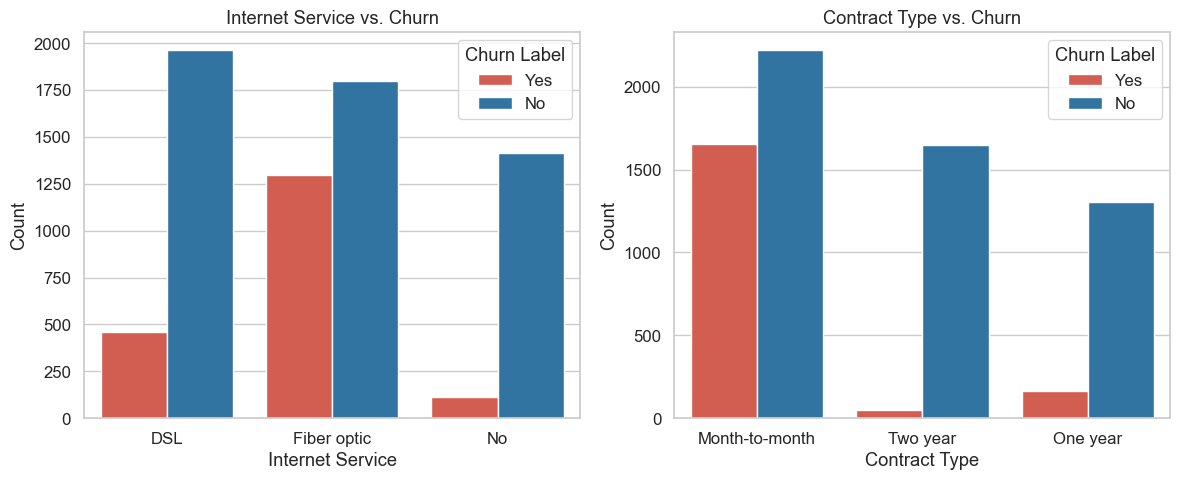

In [129]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.countplot(data=df, x="Internet Service", hue="Churn Label", palette=colors, ax=axes[0])
axes[0].set_title("Internet Service vs. Churn")
axes[0].set_xlabel("Internet Service")
axes[0].set_ylabel("Count")

sns.countplot(data=df, x="Contract", hue="Churn Label", palette=colors, ax=axes[1])
axes[1].set_title("Contract Type vs. Churn")
axes[1].set_xlabel("Contract Type")
axes[1].set_ylabel("Count")

plt.tight_layout()
plt.show()

**Insights:**

**1.Internet Service vs. Churn**
* Customers with Fiber Optic internet have the highest churn rate compared to DSL or no internet service.
* This could be due to higher pricing, service issues, or competition from other providers.
* Customers without internet service have the lowest churn rate, possibly because they only use basic phone services.

**2.Contract Type vs. Churn**
* Month-to-month contracts have the highest churn → Lack of long-term commitment makes it easier for customers to leave.
* One-year and two-year contracts show significantly lower churn → Longer commitments likely reduce churn through stability and incentives.

# **Correlation heatmap to visualize the relationships between all numerical features in the dataset.**

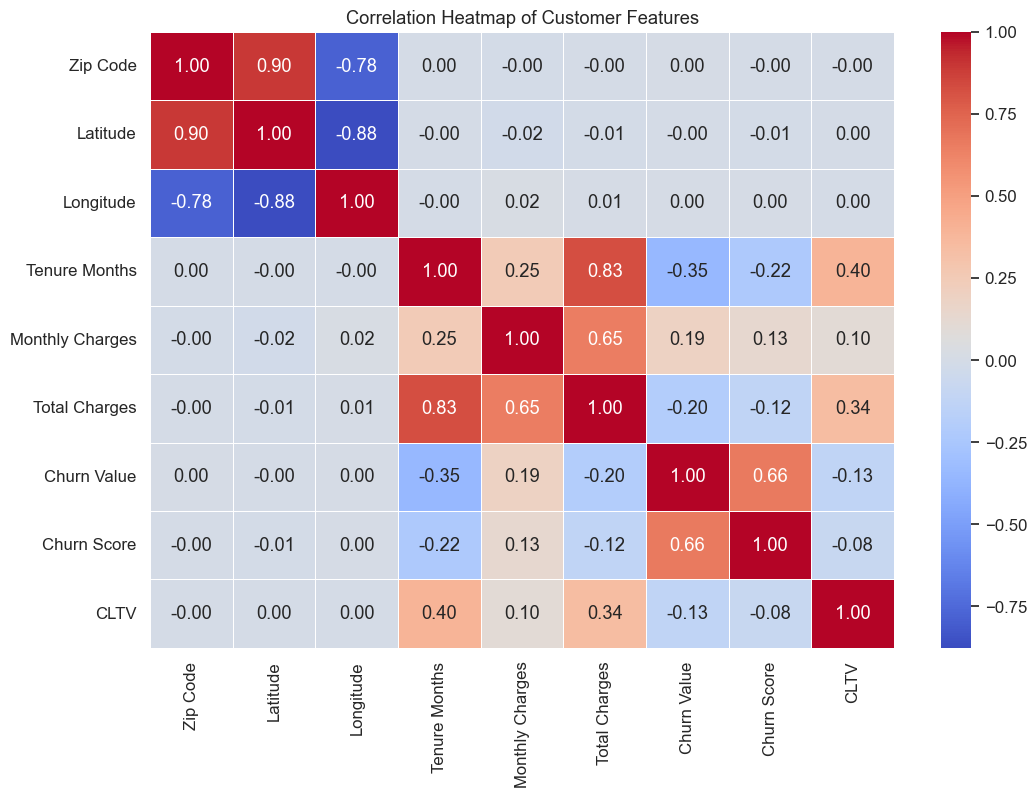

In [131]:
# Correlation cannot be calculated on strings/text
numeric_df = df.select_dtypes(include=['float64', 'int64'])

# 2. Calculate the correlation matrix
corr_matrix = numeric_df.corr()

# 3. Plot the Heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', linewidths=0.5)
plt.title('Correlation Heatmap of Customer Features')
plt.show()

* Lat Long: adds no information cause there is a seperate column for each of them
* Churn Label: same information are given by Churn value
* Churn Reason: given only for churned customers, can't be used for prediction.
* Churn Score: indicative of churn, would be target variable for a regression Model.

In [132]:
drop_columns =  ['Lat Long','Churn Label','Churn Score','Churn Reason']
df.drop(drop_columns , axis=1, inplace=True)

In [133]:
df.columns

Index(['City', 'Zip Code', 'Latitude', 'Longitude', 'Gender', 'Senior Citizen',
       'Partner', 'Dependents', 'Tenure Months', 'Phone Service',
       'Multiple Lines', 'Internet Service', 'Online Security',
       'Online Backup', 'Device Protection', 'Tech Support', 'Streaming TV',
       'Streaming Movies', 'Contract', 'Paperless Billing', 'Payment Method',
       'Monthly Charges', 'Total Charges', 'Churn Value', 'CLTV'],
      dtype='str')

# **Label Encoding**

The categorical values will be encoded into numnerical values

In [134]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

for col in df.select_dtypes(include="object").columns:
    df[col] = le.fit_transform(df[col])
    

C:\Users\jinit\AppData\Local\Temp\ipykernel_18148\671801592.py:5: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  for col in df.select_dtypes(include="object").columns:


# Store Feature Variables in X and Target in Vector Y

In [135]:
X = df.drop("Churn Value", axis=1)
X

,City,Zip Code,Latitude,Longitude,Gender,Senior Citizen,Partner,Dependents,Tenure Months,Phone Service,...,Device Protection,Tech Support,Streaming TV,Streaming Movies,Contract,Paperless Billing,Payment Method,Monthly Charges,Total Charges,CLTV
0,562,90003,33.964131,-118.272783,1,0,0,0,2,1,...,0,0,0,0,0,1,3,53.85,108.15,3239
1,562,90005,34.059281,-118.307420,0,0,0,1,2,1,...,0,0,0,0,0,1,2,70.70,151.65,2701
2,562,90006,34.048013,-118.293953,0,0,0,1,8,1,...,2,0,2,2,0,1,2,99.65,820.50,5372
3,562,90010,34.062125,-118.315709,0,0,1,1,28,1,...,2,2,2,2,0,1,2,104.80,3046.05,5003
4,562,90015,34.039224,-118.266293,1,0,0,1,49,1,...,2,0,2,2,0,1,0,103.70,5036.30,5340
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,521,92285,34.341737,-116.539416,0,0,0,0,72,1,...,1,1,1,1,2,1,0,21.15,1419.40,5306
7039,2,92301,34.667815,-117.536183,1,0,1,1,24,1,...,2,2,2,2,1,1,3,84.80,1990.50,2140
7040,22,92304,34.559882,-115.637164,0,0,1,1,72,1,...,2,0,2,2,1,1,1,103.20,7362.90,5560
7041,26,92305,34.167800,-116.864330,0,0,1,1,11,0,...,0,0,0,0,0,1,2,29.60,346.45,2793


In [136]:
Y =df["Churn Value"]
Y

0       1
1       1
2       1
3       1
4       1
       ..
7038    0
7039    0
7040    0
7041    0
7042    0
Name: Churn Value, Length: 7043, dtype: int64

# Splitting The Dataset into Training data and Testing data

In [137]:
from sklearn.model_selection import train_test_split

In [138]:
# Let's split the data into training and testing

X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size = 0.2, random_state = 42)

In [139]:
X_train

,City,Zip Code,Latitude,Longitude,Gender,Senior Citizen,Partner,Dependents,Tenure Months,Phone Service,...,Device Protection,Tech Support,Streaming TV,Streaming Movies,Contract,Paperless Billing,Payment Method,Monthly Charges,Total Charges,CLTV
2142,869,92119,32.802959,-117.027095,1,0,1,0,71,1,...,2,0,2,2,1,1,1,98.65,6962.85,5101
1623,462,95327,37.847710,-120.486589,0,0,0,0,16,1,...,2,0,0,2,0,1,1,93.20,1573.70,5497
6074,541,93543,34.505273,-117.955054,0,0,0,0,32,1,...,2,0,2,2,1,1,1,104.05,3416.85,2335
1362,292,91731,34.079934,-118.046695,0,1,1,0,24,0,...,2,0,0,2,0,1,1,40.65,933.30,3843
6754,562,90043,33.988543,-118.334081,0,0,1,1,20,1,...,1,1,1,1,0,0,3,20.05,406.05,2698
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3772,872,94118,37.781304,-122.461522,0,0,1,1,42,1,...,2,2,2,2,2,1,2,100.40,4303.65,3265
5191,479,95328,37.555631,-120.911653,0,0,0,0,39,1,...,1,1,1,1,2,0,1,20.70,762.45,3733
5226,196,95422,38.965804,-122.631779,1,0,1,1,19,1,...,1,1,1,1,2,0,3,20.20,387.40,4821
5390,855,95833,38.619049,-121.517552,1,0,1,1,35,1,...,1,1,1,1,1,0,2,19.90,666.00,2334


In [140]:
Y_train

2142    0
1623    1
6074    0
1362    1
6754    0
       ..
3772    0
5191    0
5226    0
5390    0
860     1
Name: Churn Value, Length: 5634, dtype: int64

In [141]:
X_test

,City,Zip Code,Latitude,Longitude,Gender,Senior Citizen,Partner,Dependents,Tenure Months,Phone Service,...,Device Protection,Tech Support,Streaming TV,Streaming Movies,Contract,Paperless Billing,Payment Method,Monthly Charges,Total Charges,CLTV
185,473,93531,35.214982,-118.590490,0,0,0,0,15,1,...,0,0,0,2,0,1,0,85.90,1269.55,3579
2715,972,95207,38.002125,-121.324979,1,0,1,0,18,1,...,0,0,0,0,0,0,1,56.80,1074.65,5558
3825,881,94579,37.687264,-122.157280,0,0,0,0,2,1,...,1,1,1,1,0,1,3,20.00,40.90,2237
1807,931,91423,34.146957,-118.432138,1,1,1,0,6,1,...,0,0,0,2,0,1,2,84.20,519.15,5834
132,662,92563,33.581045,-117.147190,1,0,0,0,40,1,...,2,2,2,2,0,0,0,104.80,4131.95,3492
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6366,216,95228,37.943954,-120.671080,0,1,1,1,66,1,...,2,0,2,2,1,1,2,104.90,6891.45,4892
315,632,95356,37.716186,-121.025836,1,0,0,0,19,1,...,0,0,0,2,0,1,0,86.00,1532.45,4857
2439,455,93527,36.041315,-118.188235,0,0,1,0,2,1,...,0,0,2,0,0,0,2,90.35,190.50,5361
5002,244,94506,37.791481,-121.903253,1,0,1,1,68,1,...,2,0,2,2,2,1,2,110.20,7467.50,4108


In [142]:
Y_test

185     1
2715    0
3825    0
1807    1
132     1
       ..
6366    0
315     1
2439    0
5002    0
1161    1
Name: Churn Value, Length: 1409, dtype: int64

# **Normalization Step**

In [143]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
scaler.fit(X_train)
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [144]:
X_train

array([[ 0.87626633, -0.74982381, -1.41640711, ...,  1.13316589,
         2.07084713,  0.58533508],
       [-0.41724747,  0.96541644,  0.63233942, ...,  0.95270761,
        -0.31009531,  0.91888586],
       [-0.16617231,  0.01155466, -0.72507271, ...,  1.3119686 ,
         0.50421382, -1.7444666 ],
       ...,
       [-1.26263978,  1.01621065,  1.08641361, ..., -1.46444011,
        -0.83420617,  0.34949109],
       [ 0.831772  ,  1.23596244,  0.94559137, ..., -1.4743736 ,
        -0.71111986, -1.7453089 ],
       [ 1.15912316,  1.4054547 ,  1.06439124, ...,  1.29210163,
         0.34940606,  0.82623287]], shape=(5634, 24))

# **Importing the Models**

In [145]:
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report
from sklearn.model_selection import GridSearchCV


# **Model Training and Evaluation**

# **Logistic Regression Model**

In [146]:
# 1. Corrected Hyperparameter Grid
# 'l1' and 'l2' use the letter 'l'. 
# Note: 'liblinear' solver supports l1/l2; 'lbfgs' (default) supports l2/None.
param_grid = {
    'penalty': ['l2'], # Standardizing to l2 for compatibility with the default solver
    'C': [0.001, 0.01, 0.1, 1, 10, 100],
    'max_iter': [100, 200, 300],
    'solver': ['lbfgs', 'liblinear'] # Adding solvers to ensure penalty compatibility
}

# 2. Initialize the model
lr = LogisticRegression()

# 3. Use GridSearchCV
# Increased cv to 5 for more reliable results (standard practice)
grid_search = GridSearchCV(
    estimator=lr, 
    param_grid=param_grid, 
    cv=5, 
    scoring='accuracy',
    n_jobs=-1 # Uses all processors to speed up the search
)

# 4. Fit the model
grid_search.fit(X_train, Y_train)

# 5. Output results
print("Best Hyperparameters:", grid_search.best_params_)
print("Best Accuracy Score:", grid_search.best_score_)

best_lr_model = grid_search.best_estimator_

Best Hyperparameters: {'C': 0.1, 'max_iter': 100, 'penalty': 'l2', 'solver': 'lbfgs'}
Best Accuracy Score: 0.8134575044010962


c:\Users\jinit\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(


In [147]:
log_reg = LogisticRegression(C=0.01, max_iter = 100, solver= 'lbfgs', penalty = 'l2')


In [148]:
log_reg.fit(X_train,Y_train)

c:\Users\jinit\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(


,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'l2'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",0.01
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`multiclass

In [149]:
# Make Prediction
y_pred1 = log_reg.predict(X_test)

In [150]:
# Checking for overfitting and underfitting

# Train Score
print("Train Score:",log_reg.score(X_train,Y_train))

# Test Score
print("Test Score:",log_reg.score(X_test,Y_test))

Train Score: 0.8152289669861554
Test Score: 0.7970191625266146


In [151]:
#Accuracy Score
print("Accuracy Score:",accuracy_score(Y_test,y_pred1))

Accuracy Score: 0.7970191625266146


In [152]:
# Utilizing testing set to test model

accuracy=log_reg.score(X_test,Y_test)
print("Logistic Regression")
print("Accuracy Score :",accuracy)
print(f'Accuracy in Percentage\t: {"{:.1%}".format(accuracy)}')
print(classification_report(Y_test,y_pred1))


Logistic Regression
Accuracy Score : 0.7970191625266146
Accuracy in Percentage	: 79.7%
              precision    recall  f1-score   support

           0       0.83      0.90      0.86      1009
           1       0.68      0.54      0.60       400

    accuracy                           0.80      1409
   macro avg       0.76      0.72      0.73      1409
weighted avg       0.79      0.80      0.79      1409



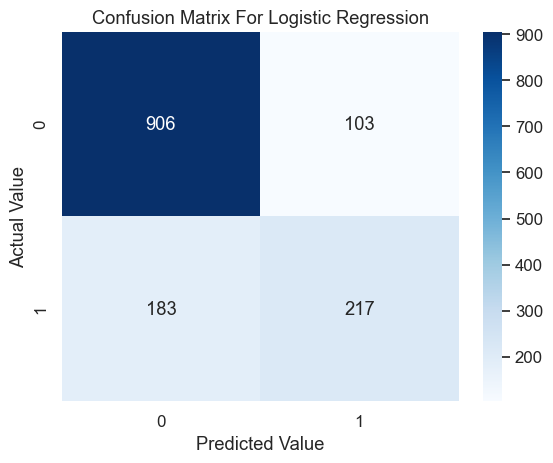

In [153]:
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(Y_test, y_pred1)

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.title("Confusion Matrix For Logistic Regression")

plt.xlabel("Predicted Value")

plt.ylabel("Actual Value")

plt.show()

# **Random Forest Classifier Model**

In [154]:
# 1. Define the Hyperparameter Grid
# n_estimators: Number of trees in the forest
# max_depth: Maximum depth of each tree
# min_samples_split: Minimum number of samples required to split an internal node
# criterion: Function to measure the quality of a split
param_grid_rf = {
    'n_estimators': [100, 200, 300],
    'max_depth': [None, 10, 20, 30],
    'min_samples_split': [2, 5, 10],
    'criterion': ['gini', 'entropy']
}

# 2. Initialize the Random Forest model
rf = RandomForestClassifier(random_state=42)

# 3. Setup GridSearchCV
# cv=5 provides a good balance between bias and variance
# n_jobs=-1 uses all available CPU cores
grid_search_rf = GridSearchCV(
    estimator=rf, 
    param_grid=param_grid_rf, 
    cv=5, 
    scoring='accuracy', 
    n_jobs=-1,
    verbose=1 # Shows progress during the search
)

# 4. Fit the model
grid_search_rf.fit(X_train, Y_train)

# 5. Output the results
print("Best Hyperparameters for Random Forest:", grid_search_rf.best_params_)
print("Best Cross-Validation Score:", grid_search_rf.best_score_)

# 6. Extract the best model
best_rf_model = grid_search_rf.best_estimator_

Fitting 5 folds for each of 72 candidates, totalling 360 fits
Best Hyperparameters for Random Forest: {'criterion': 'entropy', 'max_depth': 10, 'min_samples_split': 10, 'n_estimators': 300}
Best Cross-Validation Score: 0.8040491661951675


In [156]:
rf_cl = RandomForestClassifier(criterion = 'entropy', max_depth = 10, min_samples_split = 10, n_estimators = 300)

In [157]:
rf_cl.fit(X_train,Y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",300
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'entropy'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",10
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",10
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metr

In [158]:
# Make Prediction
y_pred2 = rf_cl.predict(X_test)

In [159]:
# Checking for the Under fitting and Over fitting

# Train Score
print("Train Score:",rf_cl.score(X_train,Y_train))

# Test Score
print("Test Score:",rf_cl.score(X_test,Y_test))


Train Score: 0.88604898828541
Test Score: 0.8048261178140526


In [160]:
#Accuracy Score
print("Accuracy Score:",accuracy_score(Y_test,y_pred2))

Accuracy Score: 0.8048261178140526


In [161]:
# Utilizing testing set to test model

accuracy=rf_cl.score(X_test,Y_test)
print("Random Forest Classifier")
print("Accuracy Score :",accuracy)
print(f'Accuracy in Percentage\t: {"{:.1%}".format(accuracy)}')
print(classification_report(Y_test,y_pred2))


Random Forest Classifier
Accuracy Score : 0.8048261178140526
Accuracy in Percentage	: 80.5%
              precision    recall  f1-score   support

           0       0.83      0.91      0.87      1009
           1       0.71      0.53      0.61       400

    accuracy                           0.80      1409
   macro avg       0.77      0.72      0.74      1409
weighted avg       0.80      0.80      0.80      1409



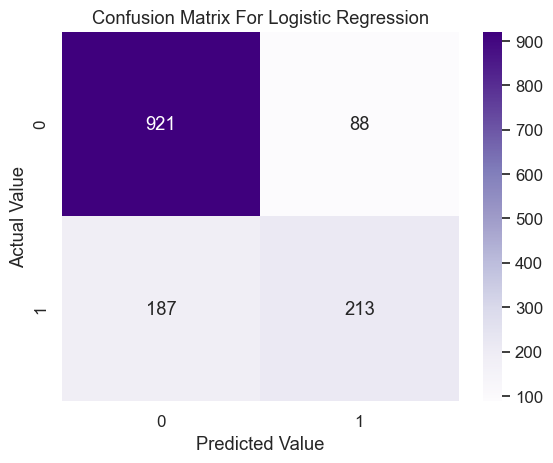

In [162]:
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(Y_test, y_pred2)

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Purples"
)

plt.title("Confusion Matrix For Logistic Regression")

plt.xlabel("Predicted Value")

plt.ylabel("Actual Value")

plt.show()

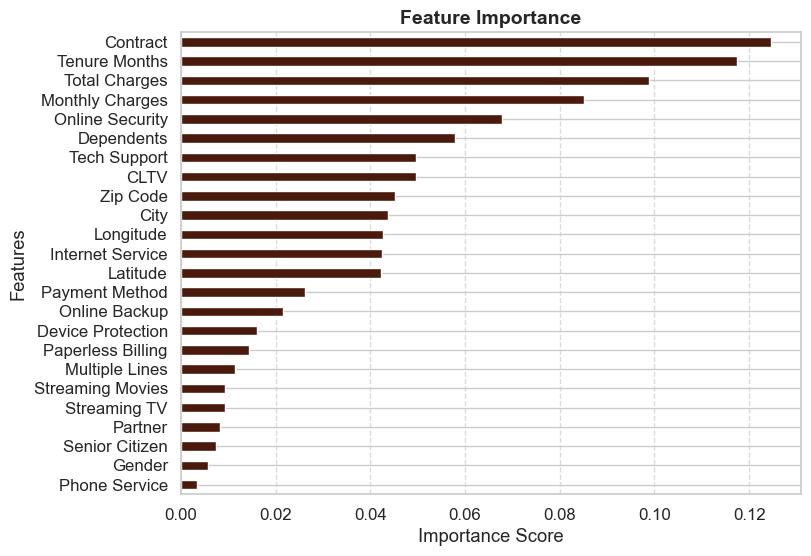

In [163]:
importance = pd.Series(
    rf_cl.feature_importances_,
    index=X.columns
)

importance.sort_values().plot(
    kind="barh",
    color="#4a1b0c",
    figsize=(8,6)
)

plt.title(
    "Feature Importance",
    fontsize = 14,
    fontweight ="bold")

plt.xlabel("Importance Score")

plt.ylabel("Features")

plt.grid(axis="x", linestyle="--", alpha=0.7)

plt.show()

# **Decision Tree Classifier** 

In [164]:
# 1. Define the Hyperparameter Grid
# max_depth: Prevents the tree from growing too deep (controls overfitting)
# min_samples_leaf: Minimum samples required to be at a leaf node
# criterion: The function to measure the quality of a split
param_grid_dt = {
    'criterion': ['gini', 'entropy'],
    'max_depth': [None, 5, 10, 15, 20],
    'min_samples_split': [2, 10, 20],
    'min_samples_leaf': [1, 5, 10]
}

# 2. Initialize the Decision Tree model
dtree = DecisionTreeClassifier(random_state=42)

# 3. Setup GridSearchCV
grid_search_dt = GridSearchCV(
    estimator=dtree,
    param_grid=param_grid_dt,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)

# 4. Fit the model
grid_search_dt.fit(X_train, Y_train)

# 5. Output results
print("Best Hyperparameters for Decision Tree:", grid_search_dt.best_params_)
print("Best Cross-Validation Score:", grid_search_dt.best_score_)

# 6. Extract the best model
best_dt_model = grid_search_dt.best_estimator_

Best Hyperparameters for Decision Tree: {'criterion': 'entropy', 'max_depth': 5, 'min_samples_leaf': 1, 'min_samples_split': 2}
Best Cross-Validation Score: 0.7848813477047317


In [165]:
dt_cl = DecisionTreeClassifier(criterion = 'gini', max_depth = 5, min_samples_leaf = 10, min_samples_split = 2)

In [166]:
dt_cl.fit(X_train,Y_train)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",5
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",10
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current

In [167]:
# Make Prediction
y_pred3 = dt_cl.predict(X_test)

In [168]:
# Checking for the Under fitting and Over fitting

# Train Score
print("Train Score:",dt_cl.score(X_train,Y_train))

# Test Score
print("Test Score:",dt_cl.score(X_test,Y_test))

Train Score: 0.8031593894213702
Test Score: 0.7920511000709723


In [169]:
#Accuracy Score
print("Accuracy Score:",accuracy_score(Y_test,y_pred3))

Accuracy Score: 0.7920511000709723


In [170]:
# Utilizing testing set to test model

accuracy=dt_cl.score(X_test,Y_test)
print("Decision Tree Classifier")
print("Accuracy Score :",accuracy)
print(f'Accuracy in Percentage\t: {"{:.1%}".format(accuracy)}')
print(classification_report(Y_test,y_pred3))


Decision Tree Classifier
Accuracy Score : 0.7920511000709723
Accuracy in Percentage	: 79.2%
              precision    recall  f1-score   support

           0       0.81      0.93      0.86      1009
           1       0.71      0.45      0.55       400

    accuracy                           0.79      1409
   macro avg       0.76      0.69      0.71      1409
weighted avg       0.78      0.79      0.78      1409



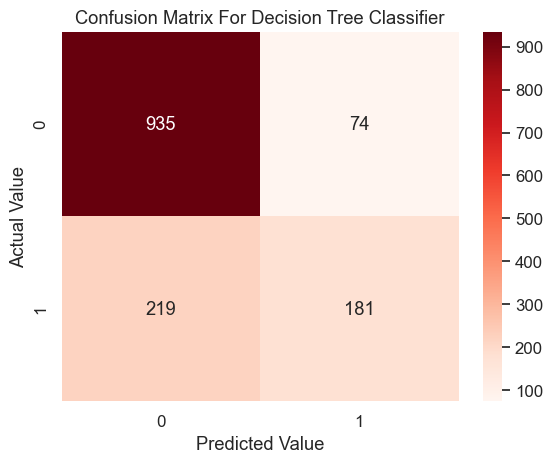

In [171]:
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(Y_test, y_pred3)

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Reds"
)

plt.title("Confusion Matrix For Decision Tree Classifier")

plt.xlabel("Predicted Value")

plt.ylabel("Actual Value")

plt.show()

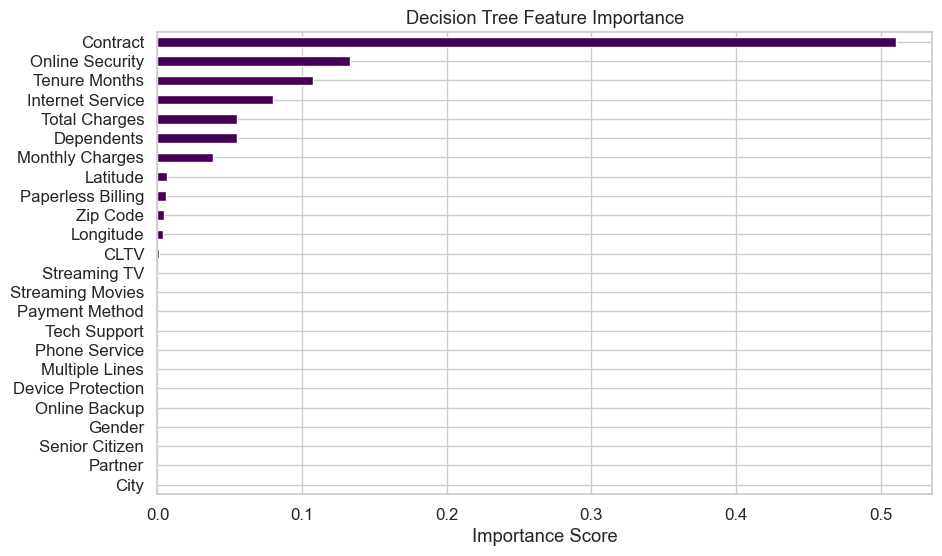

In [172]:
importance_dt = pd.Series(
    dt_cl.feature_importances_,
    index=X.columns
)

importance_dt.sort_values().plot(
    kind="barh",
    figsize=(10,6),
    colormap="viridis"
)

plt.title("Decision Tree Feature Importance")

plt.xlabel("Importance Score")

plt.show()

# **K-Nearest Neighbors Classifier(KNN)**

In [173]:
knn  =KNeighborsClassifier(n_neighbors=5)

In [174]:
# Define the hyperparameter grid
param_grid = {'n_neighbors': [3, 5, 7], 'weights': ['uniform','distance']}

knn = KNeighborsClassifier()

# Use GridSearchCv to find the best combination of Hyperparameters
grid_search = GridSearchCV(knn, param_grid, cv=5)
grid_search.fit(X_train,Y_train)

# Print the best hyperparameter values found
print("Best Hyperparameters:", grid_search.best_params_)

best_knn_model = grid_search.best_estimator_

Best Hyperparameters: {'n_neighbors': 7, 'weights': 'uniform'}


In [175]:
knn_cl= KNeighborsClassifier(n_neighbors = 7, weights = 'distance')

In [176]:
knn_cl.fit(X_train,Y_train)

,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",7
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Refer to the example entitled:ref:`sphx_glr_auto_examples_neighbors_plot_classification.py`showing the impact of the `weights` parameter on the decisionboundary.",'distance'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this is equivalentto using manhattan_distance (l1), and euclidean_distance (l2) for p = 2.For arbitrary p, minkowski_distance (l_p) is used. This parameter is expectedto be positive.",2
,"metric metric: str or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.",'minkowski'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.Doesn't affect :meth:`fit` method.",None


In [177]:
y_pred4 = knn_cl.predict(X_test)

In [178]:
# Checking for the Under fitting and Over fitting

# Train Score
print("Train Score:",knn_cl.score(X_train,Y_train))

# Test Score
print("Test Score:",knn_cl.score(X_test,Y_test))

Train Score: 1.0
Test Score: 0.7579843860894251


In [179]:
#Accuracy Score
print("Accuracy Score:",accuracy_score(Y_test,y_pred4))

Accuracy Score: 0.7579843860894251


In [180]:
# Utilizing testing set to test model

accuracy=knn_cl.score(X_test,Y_test)
print("K-Nearest Neighbors Classifier(KNN)")
print("Accuracy Score :",accuracy)
print(f'Accuracy in Percentage\t: {"{:.1%}".format(accuracy)}')
print(classification_report(Y_test,y_pred4))


K-Nearest Neighbors Classifier(KNN)
Accuracy Score : 0.7579843860894251
Accuracy in Percentage	: 75.8%
              precision    recall  f1-score   support

           0       0.82      0.85      0.83      1009
           1       0.58      0.52      0.55       400

    accuracy                           0.76      1409
   macro avg       0.70      0.68      0.69      1409
weighted avg       0.75      0.76      0.75      1409



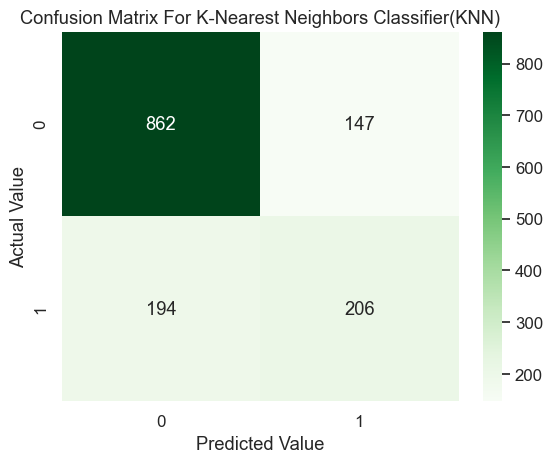

In [181]:
cm = confusion_matrix(Y_test, y_pred4)

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Greens"
)

plt.title("Confusion Matrix For K-Nearest Neighbors Classifier(KNN)")

plt.xlabel("Predicted Value")

plt.ylabel("Actual Value")

plt.show()

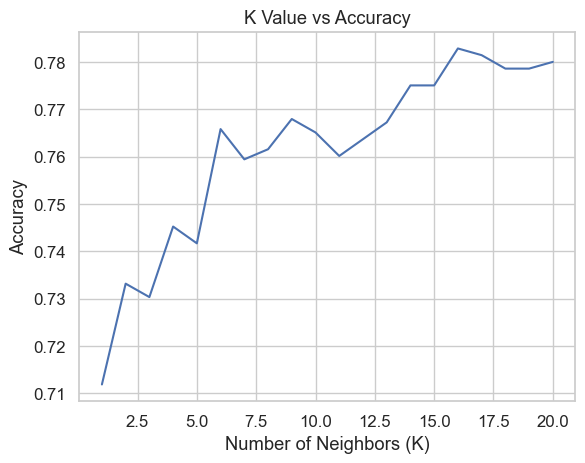

In [182]:
accuracy_scores = []

for k in range(1, 21):
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train, Y_train)
    y_pred = knn.predict(X_test)

    accuracy_scores.append(
        accuracy_score(Y_test, y_pred)
    )

plt.plot(range(1, 21), accuracy_scores)

plt.title("K Value vs Accuracy")

plt.xlabel("Number of Neighbors (K)")

plt.ylabel("Accuracy")

plt.show()

# **Support Vector Machine (SVM)**

In [183]:
from sklearn.svm import SVC

svm = SVC(
    kernel='linear',
    random_state=42
)
# 2. Define parameter grid
param_grid_svm = {
    'C': [0.1, 1, 10, 100],
    'kernel': ['linear', 'rbf', 'poly'],
    'gamma': ['scale', 'auto'],
    'degree': [2, 3]   # used only for 'poly' kernel
}

# 3. Apply GridSearchCV
grid_search_svm = GridSearchCV(
    estimator=svm,
    param_grid=param_grid_svm,
    cv=5,
    scoring='f1',     # Recommended for churn prediction
    n_jobs=-1
)

# 4. Train model
grid_search_svm.fit(X_train, Y_train)

# 5. Best results
print("Best Hyperparameters:", grid_search_svm.best_params_)
print("Best F1 Score:", grid_search_svm.best_score_)

# 6. Store best model
best_svm_model = grid_search_svm.best_estimator_


Best Hyperparameters: {'C': 10, 'degree': 2, 'gamma': 'scale', 'kernel': 'linear'}
Best F1 Score: 0.5945825870651337


In [184]:
svm_cl= SVC(C= 0.1, degree= 2, gamma= 'scale', kernel= 'linear')

In [185]:
svm_cl.fit(X_train,Y_train)

,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive. The penaltyis a squared l2 penalty. For an intuitive visualization of the effectsof scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",0.1
,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm. Ifnone is given, 'rbf' will be used. If a callable is given it is used topre-compute the kernel matrix from data matrices; that matrix should bean array of shape ``(n_samples, n_samples)``. For an intuitivevisualization of different kernel types see:ref:`sphx_glr_auto_examples_svm_plot_svm_kernels.py`.",'linear'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",2
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",'scale'
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide `.",True
,"probability probability: bool, default=FalseWhether to enable probability estimates. This must be enabled priorto calling `fit`, will slow down that method as it internally uses5-fold cross-validation, and `predict_proba` may be inconsistent with`predict`. Read more in the :ref:`User Guide `.",False
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to class_weight[i]*C forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.",None
,"verbose verbose: bool, default=FalseEnable verbose output. Note that this setting takes advantage of aper-process runtime setting in libsvm that, if enabled, may not workproperly in a multithreaded context.",False


In [186]:
y_pred5 = svm_cl.predict(X_test)

In [187]:
# Checking for the Under fitting and Over fitting

# Train Score
print("Train Score:",svm_cl.score(X_train,Y_train))

# Test Score
print("Test Score:",svm_cl.score(X_test,Y_test))

Train Score: 0.8116790912318069
Test Score: 0.7991483321504613


In [188]:
#Accuracy Score
print("Accuracy Score:",accuracy_score(Y_test,y_pred5))

Accuracy Score: 0.7991483321504613


In [189]:
# Utilizing testing set to test model

accuracy=svm_cl.score(X_test,Y_test)
print("Support Vector Machine(SVM)")
print("Accuracy Score :",accuracy)
print(f'Accuracy in Percentage\t: {"{:.1%}".format(accuracy)}')
print(classification_report(Y_test,y_pred5))


Support Vector Machine(SVM)
Accuracy Score : 0.7991483321504613
Accuracy in Percentage	: 79.9%
              precision    recall  f1-score   support

           0       0.84      0.89      0.86      1009
           1       0.67      0.57      0.62       400

    accuracy                           0.80      1409
   macro avg       0.76      0.73      0.74      1409
weighted avg       0.79      0.80      0.79      1409



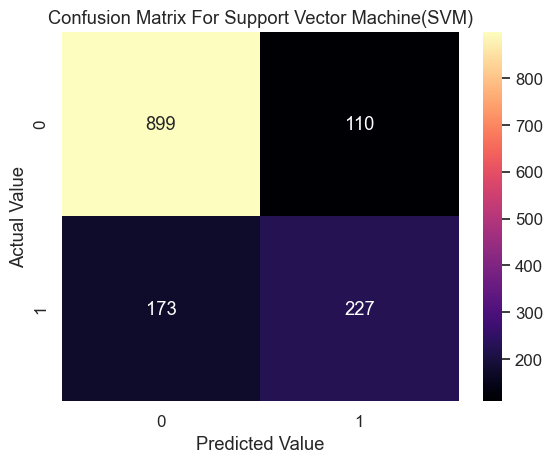

In [190]:
cm = confusion_matrix(Y_test, y_pred5)

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="magma"
)

plt.title("Confusion Matrix For Support Vector Machine(SVM)")

plt.xlabel("Predicted Value")

plt.ylabel("Actual Value")

plt.show()

# **XGBoost Classifier Model**

In [191]:
from xgboost import XGBClassifier

xgb = XGBClassifier(
    random_state=42,
    use_label_encoder=False,
    eval_metric='logloss'
)


In [192]:
# 1. Initialize model
xgb = XGBClassifier(
    objective='binary:logistic',
    eval_metric='logloss',
    random_state=42
)

# 2. Define parameter grid
param_grid_xgb = {
    'n_estimators': [100, 200],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.1],
    'subsample': [0.8, 1.0],
    'colsample_bytree': [0.8, 1.0]
}

# 3. Apply GridSearchCV
grid_search_xgb = GridSearchCV(
    estimator=xgb,
    param_grid=param_grid_xgb,
    cv=5,
    scoring='f1',     # Best for churn classification
    n_jobs=-1
)

# 4. Train model
grid_search_xgb.fit(X_train, Y_train)

# 5. Print best results
print("Best Hyperparameters:", grid_search_xgb.best_params_)
print("Best F1 Score:", grid_search_xgb.best_score_)

# 6. Store best model
best_xgb_model = grid_search_xgb.best_estimator_

Best Hyperparameters: {'colsample_bytree': 0.8, 'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 200, 'subsample': 1.0}
Best F1 Score: 0.6032007545985578


In [193]:
xgb_cl = XGBClassifier(colsample_bytree= 0.8, learning_rate= 0.1, max_depth= 3, n_estimators= 200, subsample= 0.8)

In [194]:
xgb_cl.fit(X_train,Y_train)

,"objective objective: str | xgboost.sklearn._SklObjWProto | typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]] | NoneSpecify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'binary:logistic'
,"base_score base_score: float | typing.List[float] | NoneThe initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.List[xgboost.callback.TrainingCallback] | NoneList of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: float | NoneSubsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: float | NoneSubsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: float | NoneSubsample ratio of columns when constructing each tree.,0.8
,"device device: str | None.. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: int | None.. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: str | typing.List[str | typing.Callable] | typing.Callable | None.. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_metho

In [195]:
y_pred6 = xgb_cl.predict(X_test)

In [92]:
# Checking for the Under fitting and Over fitting

# Train Score
print("Train Score:",xgb_cl.score(X_train,Y_train))

# Test Score
print("Test Score:",xgb_cl.score(X_test,Y_test))

Train Score: 0.858359957401491
Test Score: 0.7835344215755855


In [196]:
# Utilizing testing set to test model

accuracy=xgb_cl.score(X_test,Y_test)
print("XGBoost Classifier")
print("Accuracy Score :",accuracy)
print(f'Accuracy in Percentage\t: {"{:.1%}".format(accuracy)}')
print(classification_report(Y_test,y_pred6))


XGBoost Classifier
Accuracy Score : 0.7984386089425124
Accuracy in Percentage	: 79.8%
              precision    recall  f1-score   support

           0       0.84      0.89      0.86      1009
           1       0.68      0.56      0.61       400

    accuracy                           0.80      1409
   macro avg       0.76      0.73      0.74      1409
weighted avg       0.79      0.80      0.79      1409



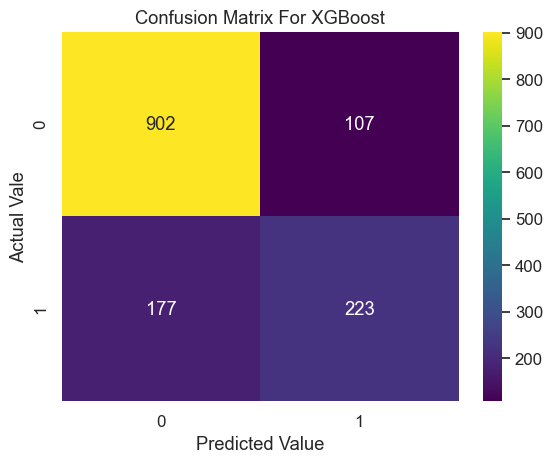

In [197]:
cm = confusion_matrix(Y_test,y_pred6)
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="viridis"
)

plt.title("Confusion Matrix For XGBoost")

plt.xlabel("Predicted Value")

plt.ylabel("Actual Vale")

plt.show()

In [198]:
Final_data = pd.DataFrame({'MODELS' : ['Logistic Regression', 'Random Forest', 'Decision Tree', 'KNN','SVN','XGBoost'],
                          'ACCURACY_SCORE' : [accuracy_score(Y_test, y_pred1),
                                        accuracy_score(Y_test, y_pred2),
                                        accuracy_score(Y_test, y_pred3),
                                        accuracy_score(Y_test, y_pred4),
                                        accuracy_score(Y_test, y_pred5),
                                        accuracy_score(Y_test,y_pred6)]})

In [199]:
Final_data

,MODELS,ACCURACY_SCORE
0,Logistic Regression,0.797019
1,Random Forest,0.804826
2,Decision Tree,0.792051
3,KNN,0.757984
4,SVN,0.799148
5,XGBoost,0.798439


C:\Users\jinit\AppData\Local\Temp\ipykernel_18148\1814664752.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


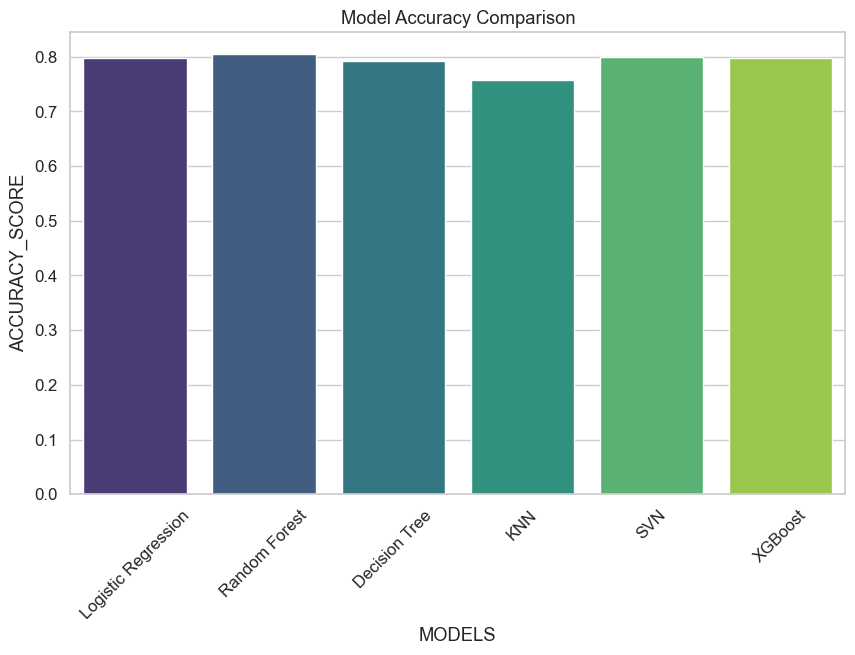

In [200]:
plt.figure(figsize=(10,6))

sns.barplot(
    x="MODELS",
    y="ACCURACY_SCORE",
    data=Final_data,
    palette="viridis"
)

plt.title("Model Accuracy Comparison")

plt.xticks(rotation=45)

plt.show()

In [204]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
import pandas as pd

def evaluate_model(model, X_test, y_test, model_name):
    
    y_pred = model.predict(X_test)
    
    # For ROC-AUC (probabilities)
    if hasattr(model, "predict_proba"):
        y_prob = model.predict_proba(X_test)[:, 1]
    else:
        y_prob = model.decision_function(X_test)

    return {
        "Model": model_name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1 Score": f1_score(y_test, y_pred),
        "ROC AUC": roc_auc_score(y_test, y_prob)
    }



In [207]:
results = []

results.append(evaluate_model(log_reg, X_test, Y_test, "Logistic Regression"))
results.append(evaluate_model(rf_cl, X_test, Y_test, "Random Forest"))
results.append(evaluate_model(dt_cl, X_test, Y_test, "Decision Tree"))
results.append(evaluate_model(knn_cl, X_test, Y_test, "KNN"))
results.append(evaluate_model(svm_cl, X_test, Y_test, "SVM"))
results.append(evaluate_model(xgb_cl, X_test, Y_test, "XGBoost"))

In [208]:
results_df = pd.DataFrame(results)

print(results_df)

                 Model  Accuracy  Precision  Recall  F1 Score   ROC AUC
0  Logistic Regression  0.797019   0.678125  0.5425  0.602778  0.850481
1        Random Forest  0.804826   0.707641  0.5325  0.607703  0.861343
2        Decision Tree  0.792051   0.709804  0.4525  0.552672  0.840723
3                  KNN  0.757984   0.583569  0.5150  0.547145  0.792231
4                  SVM  0.799148   0.673591  0.5675  0.616011  0.849009
5              XGBoost  0.798439   0.675758  0.5575  0.610959  0.860924


# **Final Conclusion**

Based on the evaluation results, the Random Forest model demonstrated the best overall performance among all models. It achieved the highest Accuracy and ROC-AUC score, indicating strong predictive capability and reliable classification of churn and non-churn customers.

The final selected model, Random Forest, can help businesses proactively identify customers at risk of churn and take targeted retention actions such as personalized offers, improved customer support, or service enhancements. This approach can reduce customer loss and improve long-term business profitability.

Overall, this project demonstrates the practical application of machine learning techniques in customer analytics and highlights the importance of model comparison and evaluation in selecting the most effective predictive model.